# 03 Model Building and Evaluation
Here is the list of the main models that we will test in this notebook:
1. Decision Tree
2. Random Forest
3. K-Nearest Neighbors (KNN)
4. Support Vector Machine (SVM)
5. Stochastic Gradient Descent (SGD)
6. Logistic Regression

## 1. Import Libraries and Load Cleaned Data

In [197]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and Statistical Methods
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier, LogisticRegression


In [198]:
# Load the cleaned dataset prepared in notebook 02
df = pd.read_csv("data/titanic_cleaned.csv")
print(df.shape)
df.head(10)

(891, 15)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Fam,Embarked_Q,Embarked_S,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior
0,1,0,3,0,22.0,1,0,7.2500,1,0,1,0,1,0,0
1,2,1,1,1,38.0,1,0,71.2833,1,0,0,0,1,0,0
2,3,1,3,1,26.0,0,0,7.9250,0,0,1,0,1,0,0
3,4,1,1,1,35.0,1,0,53.1000,1,0,1,0,1,0,0
4,5,0,3,0,35.0,0,0,8.0500,0,0,1,0,1,0,0
5,6,0,3,0,28.0,0,0,8.4583,0,1,0,0,1,0,0
6,7,0,1,0,54.0,0,0,51.8625,0,0,1,0,0,1,0
7,8,0,3,0,2.0,3,1,21.0750,4,0,1,0,0,0,0
8,9,1,3,1,27.0,0,2,11.1333,2,0,1,0,1,0,0
9,10,1,2,1,14.0,1,0,30.0708,1,0,0,1,0,0,0


## 2. Prepare Features and Target

In [199]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

print(X.shape)
print(len(y))

(891, 14)
891


We now split the data into training and testing splits for our initial model evaluation. Note that we will stratify on y to make sure that both training and testing datasets contain the same proportion of the Survived label.

In [200]:
# Train/test split by 80/20 rule
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100, stratify=y
)

A number of the learning methods used here do not work well without properly scaled data.

In [201]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Fam,Embarked_Q,Embarked_S,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior
96,-1.369894,-1.578992,-0.719808,3.148589,-0.456784,-0.46164,0.053870,-0.535472,-0.311564,-1.657519,-0.289333,-1.443001,-0.418231,5.882176
220,-0.890761,0.823235,-0.719808,-1.032163,-0.456784,-0.46164,-0.471453,-0.535472,-0.311564,0.603311,3.456220,-1.443001,-0.418231,-0.170005
870,1.620824,0.823235,-0.719808,-0.272026,-0.456784,-0.46164,-0.474497,-0.535472,-0.311564,0.603311,-0.289333,0.693000,-0.418231,-0.170005
798,1.342618,0.823235,-0.719808,0.032028,-0.456784,-0.46164,-0.487660,-0.535472,-0.311564,-1.657519,-0.289333,0.693000,-0.418231,-0.170005
837,1.493313,0.823235,-0.719808,-0.119999,-0.456784,-0.46164,-0.471453,-0.535472,-0.311564,0.603311,-0.289333,0.693000,-0.418231,-0.170005


## 3. Train Models

In [202]:
# Collate methods and scores
method = []
accuracy = []
precision  = []
recall = []
f1 = []

### 3.1 Decision Tree

Accuracy: 0.7877094972067039

Precision: 0.7681159420289855

Recall: 0.7066666666666667

F1 Score: 0.7361111111111112

Confusion Matrix
[[88 16]
 [22 53]]


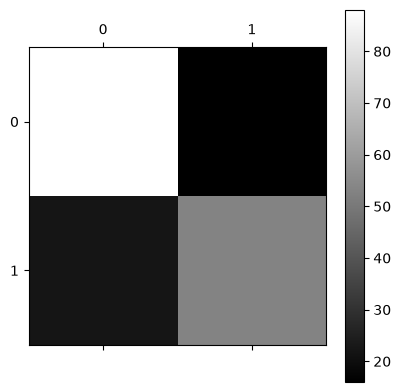

In [203]:
tree_clf = DecisionTreeClassifier(random_state=100)
method.append("Decision Tree")
tree_clf.fit(X_train, y_train)

tree_y_pred = tree_clf.predict(X_test)

# Accuracy
tree_acc = accuracy_score(tree_y_pred, y_test)
print(f"Accuracy: {tree_acc}")
accuracy.append(tree_acc)
print()

# Precision
tree_pre = precision_score(tree_y_pred, y_test)
print(f"Precision: {tree_pre}")
precision.append(tree_pre)
print()

# Recall
tree_rec = recall_score(tree_y_pred, y_test)
print(f"Recall: {tree_rec}")
recall.append(tree_rec)
print()

# F1 Score
tree_f1 = f1_score(tree_y_pred, y_test)
print(f"F1 Score: {tree_f1}")
f1.append(tree_f1)
print()

# Confusion Matrix
print("Confusion Matrix")
tree_conf_mx = confusion_matrix(tree_y_pred, y_test)
print(tree_conf_mx)
plt.matshow(tree_conf_mx, cmap=plt.cm.gray)
plt.colorbar()
plt.show()


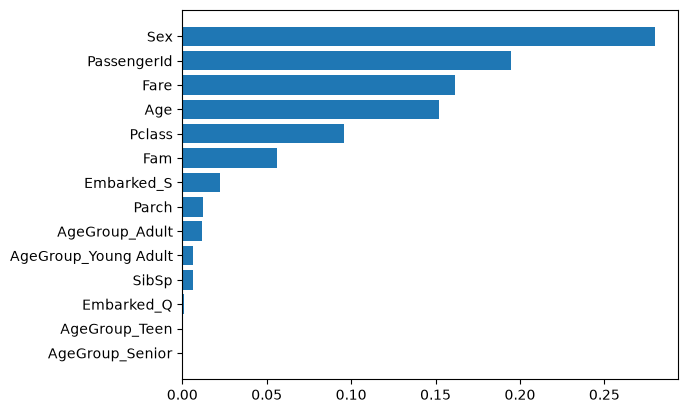

In [204]:
feature_importance = pd.Series(tree_clf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.barh(feature_importance.index, feature_importance.values)
plt.show()

### 3.2 Random Forest

Accuracy: 0.8659217877094972

Precision: 0.8405797101449275

Recall: 0.8169014084507042

F1 Score: 0.8285714285714286

Confusion Matrix
[[97 11]
 [13 58]]


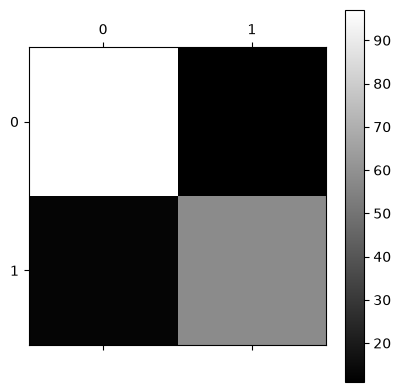

In [205]:
forest_clf = RandomForestClassifier(random_state=100)
method.append("Random Forest")
forest_clf.fit(X_train, y_train)

forest_y_pred = forest_clf.predict(X_test)

# Accuracy
forest_acc = accuracy_score(forest_y_pred, y_test)
print(f"Accuracy: {forest_acc}")
accuracy.append(forest_acc)
print()

# Precision
forest_pre = precision_score(forest_y_pred, y_test)
print(f"Precision: {forest_pre}")
precision.append(forest_pre)
print()

# Recall
forest_rec = recall_score(forest_y_pred, y_test)
print(f"Recall: {forest_rec}")
recall.append(forest_rec)
print()

# F1 Score
forest_f1 = f1_score(forest_y_pred, y_test)
print(f"F1 Score: {forest_f1}")
f1.append(forest_f1)
print()

# Confusion Matrix
print("Confusion Matrix")
forest_conf_mx = confusion_matrix(forest_y_pred, y_test)
print(forest_conf_mx)
plt.matshow(forest_conf_mx, cmap=plt.cm.gray)
plt.colorbar()
plt.show()

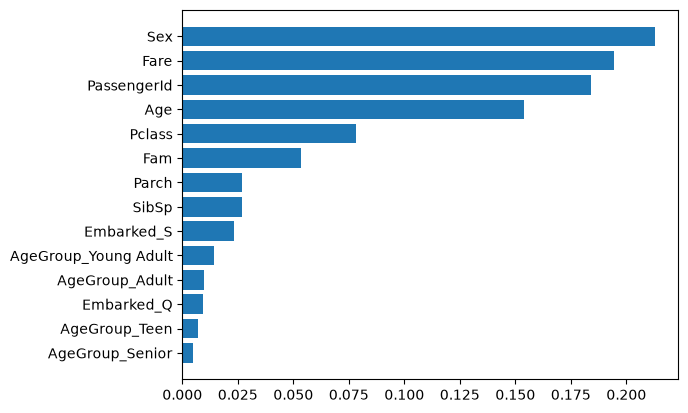

In [206]:
feature_importance = pd.Series(forest_clf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.barh(feature_importance.index, feature_importance.values)
plt.show()

### 3.3 K-Nearest Neighbors

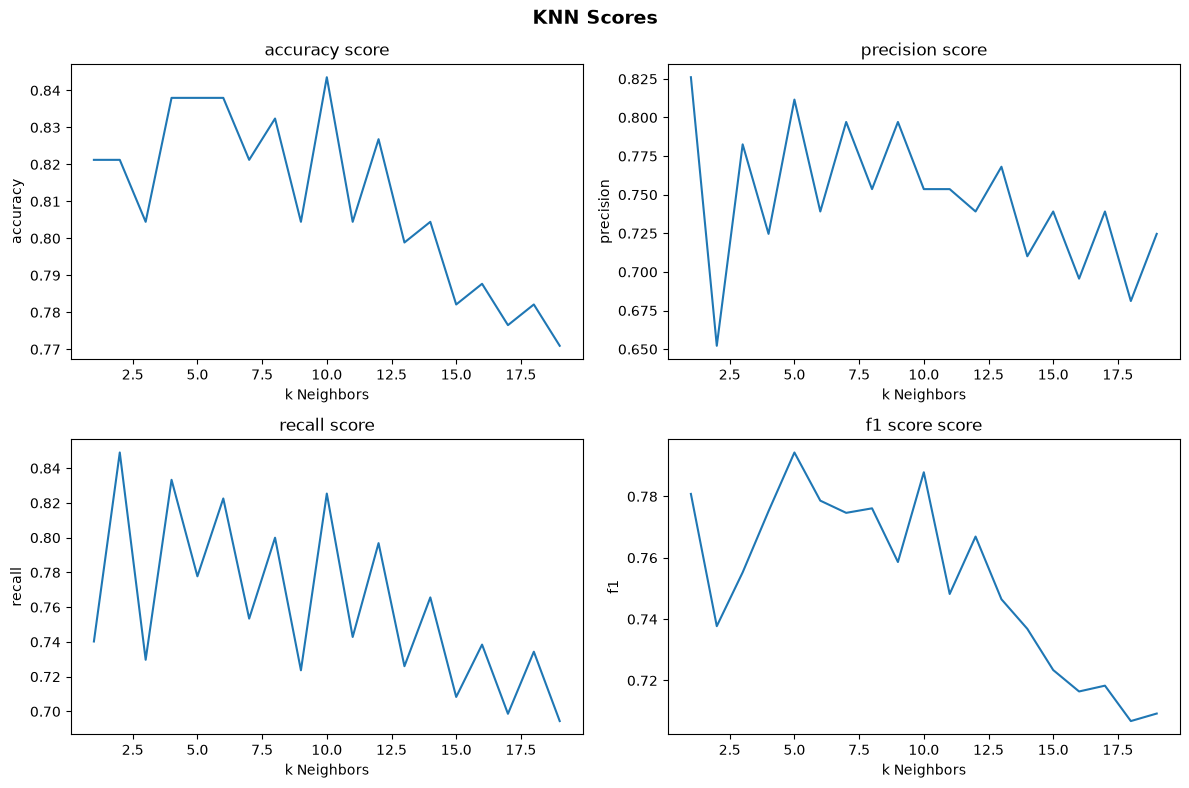

In [207]:
k_range = range(1,20)
k_acc = []
k_pre = []
k_rec = []
k_f1 = []

for k in k_range:
    KNN_clf = KNeighborsClassifier(n_neighbors=k)
    KNN_clf.fit(X_train, y_train)
    KNN_y_pred = KNN_clf.predict(X_test)
    k_acc.append(accuracy_score(KNN_y_pred, y_test))
    k_pre.append(precision_score(KNN_y_pred, y_test))
    k_rec.append(recall_score(KNN_y_pred, y_test))
    k_f1.append(f1_score(KNN_y_pred, y_test))


# Plot results

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    squeeze=False
)
axes = axes.flatten()

axes[0].plot(k_range, k_acc)
axes[0].set_xlabel("k Neighbors")
axes[0].set_ylabel("accuracy")
axes[0].set_title("accuracy score")

axes[1].plot(k_range, k_pre)
axes[1].set_xlabel("k Neighbors")
axes[1].set_ylabel("precision")
axes[1].set_title("precision score")

axes[2].plot(k_range, k_rec)
axes[2].set_xlabel("k Neighbors")
axes[2].set_ylabel("recall")
axes[2].set_title("recall score")

axes[3].plot(k_range, k_f1)
axes[3].set_xlabel("k Neighbors")
axes[3].set_ylabel("f1")
axes[3].set_title("f1 score score")

plt.suptitle("KNN Scores", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

From the above, it seems that k=10 nearest neighbors is optimal, though very noisy, so shouldn't necessarily hold to this, especially with cross-evaluation which may smooth these scores.

Accuracy: 0.8435754189944135

Precision: 0.7536231884057971

Recall: 0.8253968253968254

F1 Score: 0.7878787878787878

Confusion Matrix
[[99 17]
 [11 52]]


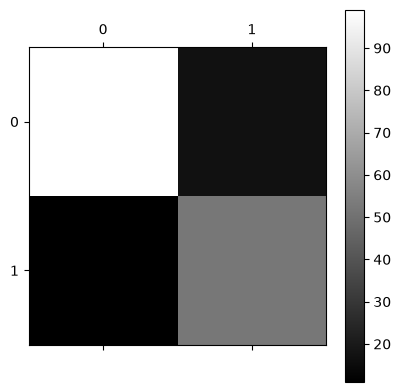

In [208]:
KNN_clf = KNeighborsClassifier(n_neighbors=10)
method.append("K-Nearest Neighbors")
KNN_clf.fit(X_train, y_train)

KNN_y_pred = KNN_clf.predict(X_test)

# Accuracy
KNN_acc = accuracy_score(KNN_y_pred, y_test)
print(f"Accuracy: {KNN_acc}")
accuracy.append(KNN_acc)
print()

# Precision
KNN_pre = precision_score(KNN_y_pred, y_test)
print(f"Precision: {KNN_pre}")
precision.append(KNN_pre)
print()

# Recall
KNN_rec = recall_score(KNN_y_pred, y_test)
print(f"Recall: {KNN_rec}")
recall.append(KNN_rec)
print()

# F1 Score
KNN_f1 = f1_score(KNN_y_pred, y_test)
print(f"F1 Score: {KNN_f1}")
f1.append(KNN_f1)
print()

# Confusion Matrix
print("Confusion Matrix")
KNN_conf_mx = confusion_matrix(KNN_y_pred, y_test)
print(KNN_conf_mx)
plt.matshow(KNN_conf_mx, cmap=plt.cm.gray)
plt.colorbar()
plt.show()

### 3.4 Support Vector Machine

Accuracy: 0.8491620111731844

Precision: 0.8115942028985508

Recall: 0.8

F1 Score: 0.8057553956834532

Confusion Matrix
[[96 13]
 [14 56]]


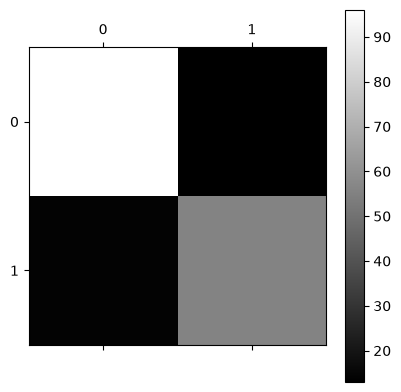

In [209]:
SVM_clf = SVC(random_state=100)
method.append("Support Vector Machine")
SVM_clf.fit(X_train, y_train)

SVM_y_pred = SVM_clf.predict(X_test)

# Accuracy
SVM_acc = accuracy_score(SVM_y_pred, y_test)
print(f"Accuracy: {SVM_acc}")
accuracy.append(SVM_acc)
print()

# Precision
SVM_pre = precision_score(SVM_y_pred, y_test)
print(f"Precision: {SVM_pre}")
precision.append(SVM_pre)
print()

# Recall
SVM_rec = recall_score(SVM_y_pred, y_test)
print(f"Recall: {SVM_rec}")
recall.append(SVM_rec)
print()

# F1 Score
SVM_f1 = f1_score(SVM_y_pred, y_test)
print(f"F1 Score: {SVM_f1}")
f1.append(SVM_f1)
print()

# Confusion Matrix
print("Confusion Matrix")
SVM_conf_mx = confusion_matrix(SVM_y_pred, y_test)
print(SVM_conf_mx)
plt.matshow(SVM_conf_mx, cmap=plt.cm.gray)
plt.colorbar()
plt.show()

### 3.5 Stochastic Gradient Descent

Accuracy: 0.776536312849162

Precision: 0.7971014492753623

Recall: 0.6790123456790124

F1 Score: 0.7333333333333333

Confusion Matrix
[[84 14]
 [26 55]]


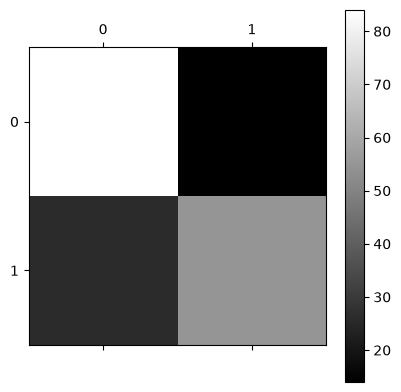

In [210]:
sgd_clf = SGDClassifier(random_state=100)
method.append("Stochastic Gradient Descent")
sgd_clf.fit(X_train, y_train)

sgd_y_pred = sgd_clf.predict(X_test)

# Accuracy
sgd_acc = accuracy_score(sgd_y_pred, y_test)
print(f"Accuracy: {sgd_acc}")
accuracy.append(sgd_acc)
print()

# Precision
sgd_pre = precision_score(sgd_y_pred, y_test)
print(f"Precision: {sgd_pre}")
precision.append(sgd_pre)
print()

# Recall
sgd_rec = recall_score(sgd_y_pred, y_test)
print(f"Recall: {sgd_rec}")
recall.append(sgd_rec)
print()

# F1 Score
sgd_f1 = f1_score(sgd_y_pred, y_test)
print(f"F1 Score: {sgd_f1}")
f1.append(sgd_f1)
print()

# Confusion Matrix
print("Confusion Matrix")
sgd_conf_mx = confusion_matrix(sgd_y_pred, y_test)
print(sgd_conf_mx)
plt.matshow(sgd_conf_mx, cmap=plt.cm.gray)
plt.colorbar()
plt.show()

### 3.6 Logistic Regression

Accuracy: 0.8156424581005587

Precision: 0.782608695652174

Recall: 0.75

F1 Score: 0.7659574468085106

Confusion Matrix
[[92 15]
 [18 54]]


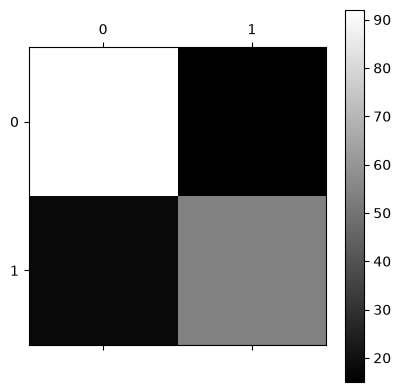

In [211]:
log_clf = LogisticRegression(random_state=100, max_iter=10000)
method.append("Logistic Regression")
log_clf.fit(X_train, y_train)

log_y_pred = log_clf.predict(X_test)

# Accuracy
log_acc = accuracy_score(log_y_pred, y_test)
print(f"Accuracy: {log_acc}")
accuracy.append(log_acc)
print()

# Precision
log_pre = precision_score(log_y_pred, y_test)
print(f"Precision: {log_pre}")
precision.append(log_pre)
print()

# Recall
log_rec = recall_score(log_y_pred, y_test)
print(f"Recall: {log_rec}")
recall.append(log_rec)
print()

# F1 Score
log_f1 = f1_score(log_y_pred, y_test)
print(f"F1 Score: {log_f1}")
f1.append(log_f1)
print()

# Confusion Matrix
print("Confusion Matrix")
log_conf_mx = confusion_matrix(log_y_pred, y_test)
print(log_conf_mx)
plt.matshow(log_conf_mx, cmap=plt.cm.gray)
plt.colorbar()
plt.show()

## 4. Model Evaluation

### 4.1 Metric Comparison

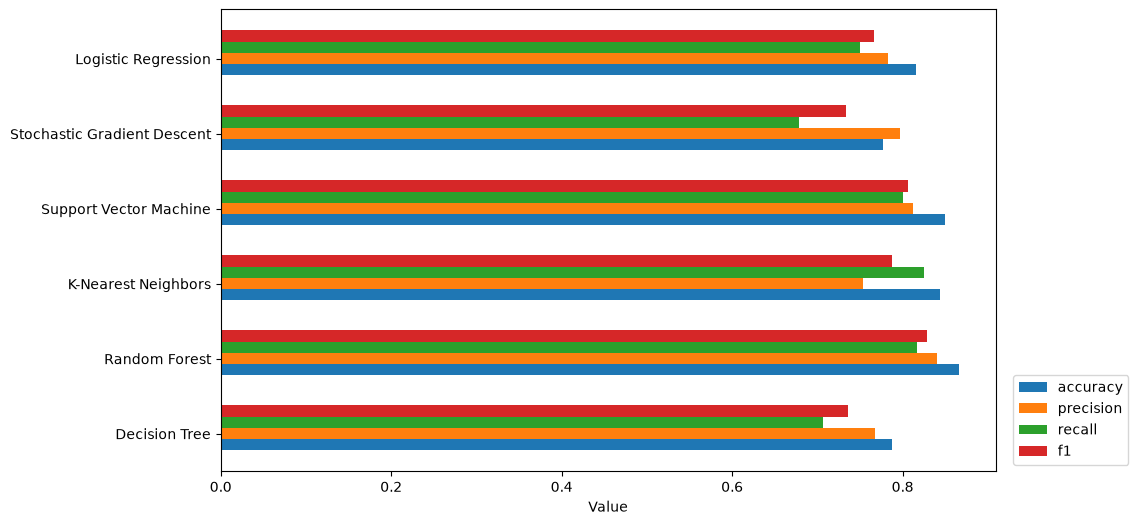

In [212]:
x = np.arange(len(method))

width = 0.15

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(x - width, accuracy, width, label="accuracy")
ax.barh(x,         precision, width, label="precision")
ax.barh(x + width, recall, width, label="recall")
ax.barh(x + 2*width, f1, width, label="f1")

ax.set_yticks(x)
ax.set_yticklabels(method)

ax.set_xlabel("Value")
ax.legend(loc="lower right", bbox_to_anchor=(1.18,0))

plt.show()

From the above, it seems that **Random Forest** performs the best.

### 4.2 Cross-Validation

In [182]:
cv_results = {}

cv_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=100),
    "Random Forest": RandomForestClassifier(random_state=100),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=10),
    "Support Vector Machine": SVC(random_state=100),
    "Stochastic Gradient Descent": SGDClassifier(random_state=100),
    "Logistic Regression": LogisticRegression(random_state=100, max_iter=10000)
}

for name, model in cv_models.items():
    cv_results[name] = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy")


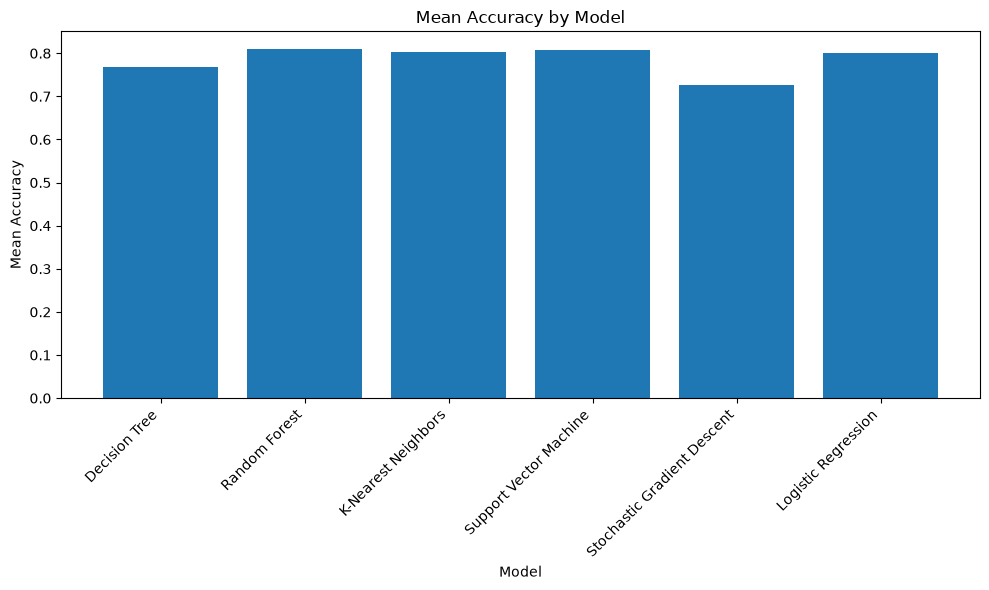

In [183]:
model_names = list(cv_results.keys())
mean_accuracies = [np.mean(scores) for scores in cv_results.values()]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(model_names, mean_accuracies)

ax.set_xlabel("Model")
ax.set_ylabel("Mean Accuracy")
ax.set_title("Mean Accuracy by Model")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 4.3 ROC Curve Comparison

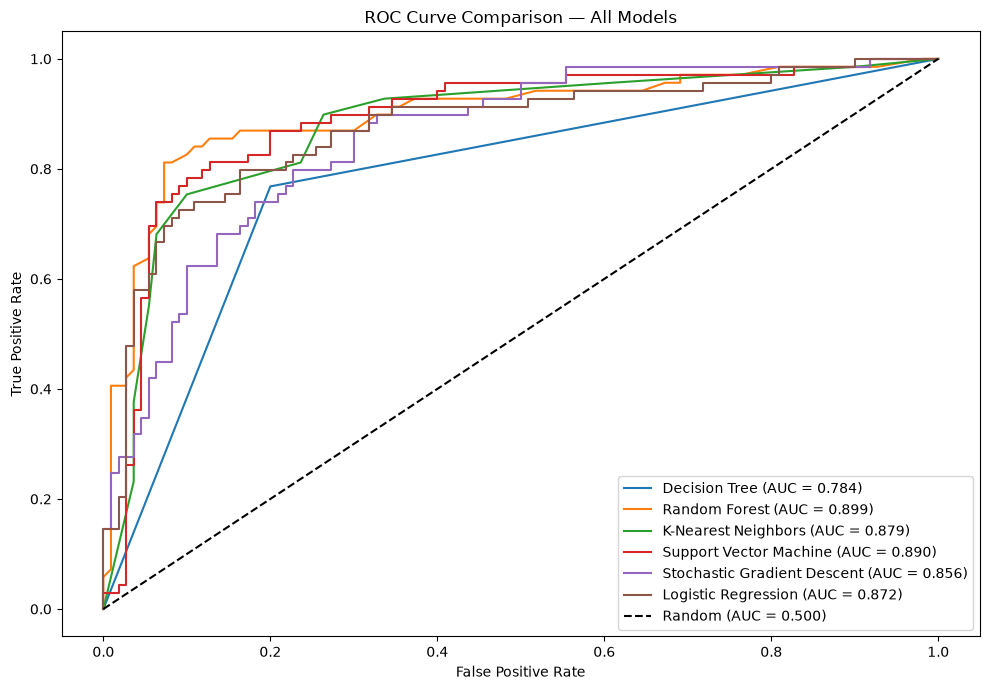

In [185]:
ROC_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=100),
    "Random Forest": RandomForestClassifier(random_state=100),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=10),
    "Support Vector Machine": SVC(random_state=100),
    "Stochastic Gradient Descent": SGDClassifier(random_state=100),
    "Logistic Regression": LogisticRegression(random_state=100, max_iter=10000)
}

plt.figure(figsize=(10, 7))

for name, model in ROC_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 4.4 Summary of Findings
From the above analysis, we have found that the **random forest** consistently performs the best of all trained models in each metric studied. We will therefore select this model as our core ML method for the following, fine-tuning the parameters.

## 5. Fine-Tuning Parameters - Random Forest

### 5.1 Fine-Tuning (GridSearchCV)

In [220]:
param_grid = {
    "n_estimators": [45, 50, 55],
    "max_depth": [6, 7, 8],
    "min_samples_split": [7, 8, 9],
    "min_samples_leaf": [1, 2, 3]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=100),
    param_grid,
    cv=5,
    scoring="f1"
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1 Score: {grid_search.best_score_}")

Best parameters: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 50}
Best F1 Score: 0.7505413272940452


### 5.2 Fine-Tuned Model Scores

Accuracy: 0.8659217877094972

Precision: 0.8260869565217391

Recall: 0.8260869565217391

F1 Score: 0.8260869565217391

Confusion Matrix
[[98 12]
 [12 57]]


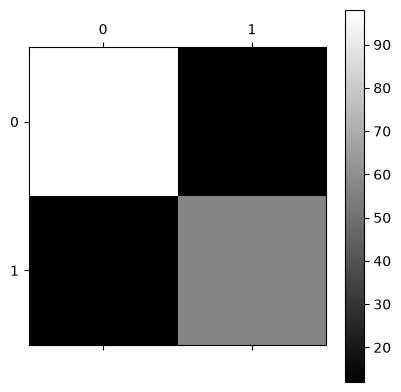

In [232]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)


# Accuracy
forest_acc = accuracy_score(y_pred_tuned, y_test)
print(f"Accuracy: {forest_acc}")
print()

# Precision
forest_pre = precision_score(y_pred_tuned, y_test)
print(f"Precision: {forest_pre}")
print()

# Recall
forest_rec = recall_score(y_pred_tuned, y_test)
print(f"Recall: {forest_rec}")
print()

# F1 Score
forest_f1 = f1_score(y_pred_tuned, y_test)
print(f"F1 Score: {forest_f1}")
print()

# Confusion Matrix
print("Confusion Matrix")
forest_conf_mx = confusion_matrix(y_pred_tuned, y_test)
print(forest_conf_mx)
plt.matshow(forest_conf_mx, cmap=plt.cm.gray)
plt.colorbar()
plt.show()

In [233]:
best_rf = grid_search.best_estimator_
best_rf_acc = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="accuracy")
best_rf_pre = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="precision")
best_rf_rec = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="recall")
best_rf_f1 = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="f1")

print(f"Accuracy: {best_rf_acc.mean()} \u00B1 {best_rf_acc.std()}")
print(f"Precision: {best_rf_pre.mean()} \u00B1 {best_rf_pre.std()}")
print(f"Recall: {best_rf_rec.mean()} \u00B1 {best_rf_rec.std()}")
print(f"F1: {best_rf_f1.mean()} \u00B1 {best_rf_f1.std()}")

Accuracy: 0.8201516793066089 ± 0.026614857734681877
Precision: 0.8095797546744367 ± 0.07608034786024158
Recall: 0.7070707070707071 ± 0.06446242039839281
F1: 0.7505413272940452 ± 0.03603760587348979


### 5.3 Feature Importance in Tuned Model

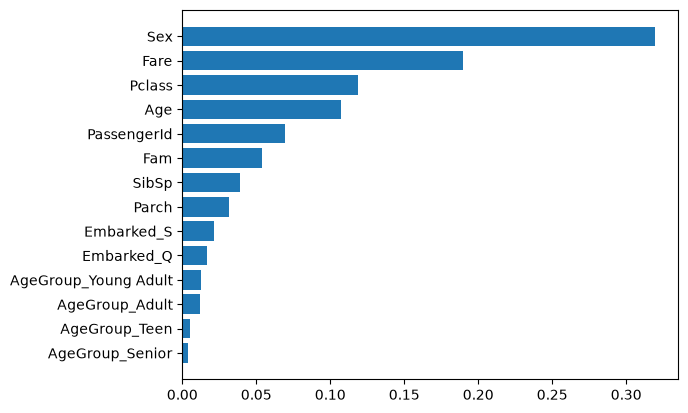

In [219]:
feature_importance = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.barh(feature_importance.index, feature_importance.values)
plt.show()

## 6. Final Summary
Final results on the test dataset:

|Model|Accuracy|Precision|Recall|F1|
|-|-|-|-|-|
|Decision Tree|0.79|0.77|0.71|0.74|
|Random Forest|0.87|0.84|0.82|0.83|
|K-Nearest Neighbors|0.84|0.75|0.83|0.79|
|Support Vector Machine|0.85|0.81|0.80|0.81|
|Stochastic Gradient Descent|0.78|0.80|0.68|0.73|
|Logistic Regression|0.82|0.78|0.75|0.77|
|Tuned Random Forest|0.87|0.83|0.83|0.83|

#### Key Takeaways

1. **Sex** was by far the most important feature for predicting survival
2. **Feature engineering** (e.g. Fam, AgeGroup) did not have a significant impact on model performance
3. **Model tuning** with GridSearchCV meaningfully improved the Random Forest model
4. There was no strictly obvious outlier in models
5. Data standardization was utilized to improve model accuracy